# Text Classification Model Training
## TF-IDF + Logistic Regression for Category and Urgency Classification

This notebook trains two text classifiers:
1. **Category Classifier**: Predicts the home service category (plumbing, painting, roofing, electrical, hvac, general_repair)
2. **Urgency Classifier**: Predicts urgency level (low, medium, high, emergency)

We use TF-IDF vectorization with Logistic Regression — a lightweight, interpretable approach well-suited for structured text classification on moderate-sized datasets.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

# Setup paths
PROJECT_ROOT = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'texts', 'job_descriptions.csv')
MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
FIGURE_DIR = os.path.join(PROJECT_ROOT, 'report', 'figures')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete.')

Setup complete.


## 1. Load and Prepare Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Total samples: {len(df)}')
print(f'\nCategory distribution:\n{df["category"].value_counts()}')
print(f'\nUrgency distribution:\n{df["urgency"].value_counts()}')
df.head()

Total samples: 357

Category distribution:
category
plumbing          74
general_repair    70
electrical        56
hvac              55
painting          51
roofing           51
Name: count, dtype: int64

Urgency distribution:
urgency
low          141
medium       130
high          63
emergency     23
Name: count, dtype: int64


,text,category,urgency,scope
0,"Small drip under the kitchen sink, been going ...",plumbing,low,small
1,"Need to replace the kitchen faucet, it's old a...",plumbing,low,medium
2,Looking to repipe the whole bathroom with copp...,plumbing,low,large
3,The toilet keeps running after flushing. I've ...,plumbing,low,small
4,Want to install a new garbage disposal and con...,plumbing,low,medium


## 2. Text Preprocessing and TF-IDF Vectorization

In [3]:
# Clean text
df['text_clean'] = df['text'].str.lower().str.replace(r'[^a-z\s]', ' ', regex=True).str.strip()

# Split data - stratify by category
X = df['text_clean']
y_cat = df['category']
y_urg = df['urgency']

X_train, X_temp, y_cat_train, y_cat_temp, y_urg_train, y_urg_temp = train_test_split(
    X, y_cat, y_urg, test_size=0.3, random_state=42, stratify=y_cat
)
X_val, X_test, y_cat_val, y_cat_test, y_urg_val, y_urg_test = train_test_split(
    X_temp, y_cat_temp, y_urg_temp, test_size=0.5, random_state=42, stratify=y_cat_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigrams and bigrams
    stop_words='english',
    min_df=2,
    max_df=0.95,
)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(X_test)

print(f'\nTF-IDF vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Feature matrix shape: {X_train_vec.shape}')

Train: 249 | Val: 54 | Test: 54

TF-IDF vocabulary size: 602
Feature matrix shape: (249, 602)


## 3. Train Category Classifier

In [4]:
# Train Logistic Regression for category classification
cat_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
)
cat_model.fit(X_train_vec, y_cat_train)

# Cross-validation score
cv_scores = cross_val_score(cat_model, X_train_vec, y_cat_train, cv=5, scoring='f1_macro')
print(f'Category Classifier - 5-Fold CV F1 (macro): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

# Validation performance
y_cat_val_pred = cat_model.predict(X_val_vec)
print(f'\nValidation Accuracy: {accuracy_score(y_cat_val, y_cat_val_pred):.4f}')
print(f'Validation F1 (macro): {f1_score(y_cat_val, y_cat_val_pred, average="macro"):.4f}')
print(f'\nClassification Report (Validation):\n')
print(classification_report(y_cat_val, y_cat_val_pred))

Category Classifier - 5-Fold CV F1 (macro): 0.8084 (+/- 0.0440)

Validation Accuracy: 0.8519
Validation F1 (macro): 0.8628

Classification Report (Validation):

                precision    recall  f1-score   support

    electrical       0.88      0.88      0.88         8
general_repair       0.69      0.82      0.75        11
          hvac       1.00      0.88      0.93         8
      painting       0.86      0.75      0.80         8
      plumbing       0.82      0.82      0.82        11
       roofing       1.00      1.00      1.00         8

      accuracy                           0.85        54
     macro avg       0.87      0.86      0.86        54
  weighted avg       0.86      0.85      0.85        54



Test Accuracy: 0.8889
Test F1 (macro): 0.8840

Classification Report (Test):

                precision    recall  f1-score   support

    electrical       0.80      0.89      0.84         9
general_repair       0.89      0.80      0.84        10
          hvac       1.00      0.89      0.94         9
      painting       0.80      1.00      0.89         8
      plumbing       0.92      1.00      0.96        11
       roofing       1.00      0.71      0.83         7

      accuracy                           0.89        54
     macro avg       0.90      0.88      0.88        54
  weighted avg       0.90      0.89      0.89        54



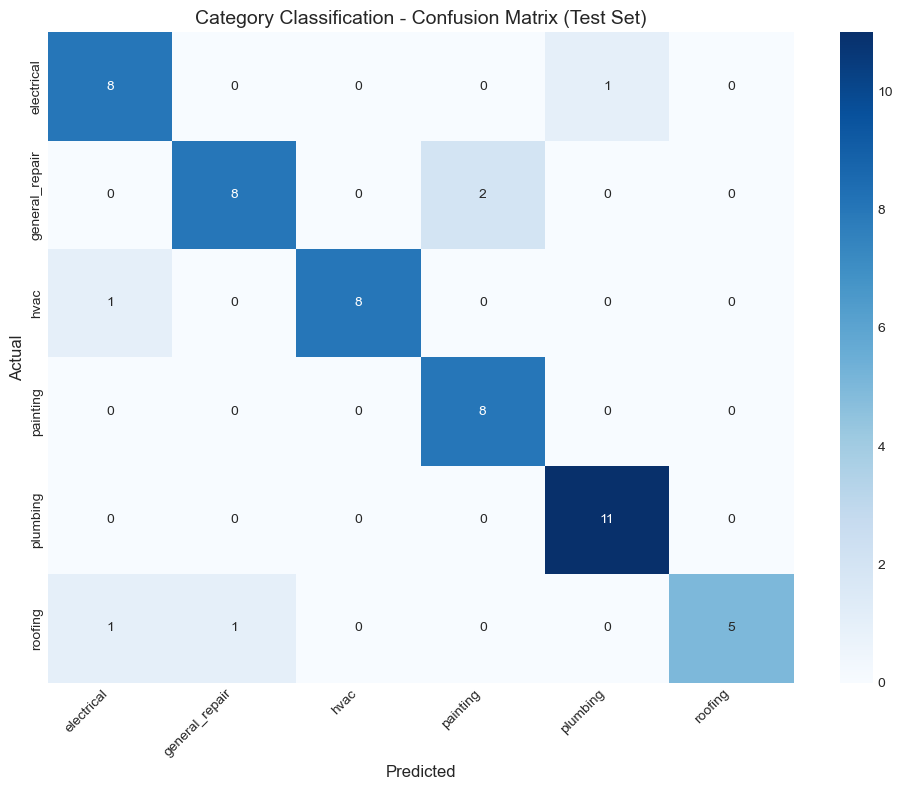

In [5]:
# Test performance - Category
y_cat_test_pred = cat_model.predict(X_test_vec)
print(f'Test Accuracy: {accuracy_score(y_cat_test, y_cat_test_pred):.4f}')
print(f'Test F1 (macro): {f1_score(y_cat_test, y_cat_test_pred, average="macro"):.4f}')
print(f'\nClassification Report (Test):\n')
print(classification_report(y_cat_test, y_cat_test_pred))

# Confusion Matrix
cm_cat = confusion_matrix(y_cat_test, y_cat_test_pred, labels=cat_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_model.classes_, yticklabels=cat_model.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Category Classification - Confusion Matrix (Test Set)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'text_category_confusion_matrix.png'), dpi=150)
plt.show()

## 4. Train Urgency Classifier

In [6]:
# Train Logistic Regression for urgency classification
urg_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
)
urg_model.fit(X_train_vec, y_urg_train)

# Cross-validation
cv_scores_urg = cross_val_score(urg_model, X_train_vec, y_urg_train, cv=5, scoring='f1_macro')
print(f'Urgency Classifier - 5-Fold CV F1 (macro): {cv_scores_urg.mean():.4f} (+/- {cv_scores_urg.std():.4f})')

# Validation
y_urg_val_pred = urg_model.predict(X_val_vec)
print(f'\nValidation Accuracy: {accuracy_score(y_urg_val, y_urg_val_pred):.4f}')
print(f'Validation F1 (macro): {f1_score(y_urg_val, y_urg_val_pred, average="macro"):.4f}')
print(f'\nClassification Report (Validation):\n')
print(classification_report(y_urg_val, y_urg_val_pred))

Urgency Classifier - 5-Fold CV F1 (macro): 0.3549 (+/- 0.0497)

Validation Accuracy: 0.6111
Validation F1 (macro): 0.3853

Classification Report (Validation):

              precision    recall  f1-score   support

   emergency       0.00      0.00      0.00         6
        high       0.50      0.12      0.20         8
         low       0.69      0.92      0.79        24
      medium       0.50      0.62      0.56        16

    accuracy                           0.61        54
   macro avg       0.42      0.42      0.39        54
weighted avg       0.53      0.61      0.54        54



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Test Accuracy: 0.5741
Test F1 (macro): 0.3462

Classification Report (Test):

              precision    recall  f1-score   support

   emergency       0.00      0.00      0.00         6
        high       0.00      0.00      0.00        10
         low       0.61      0.88      0.72        16
      medium       0.59      0.77      0.67        22

    accuracy                           0.57        54
   macro avg       0.30      0.41      0.35        54
weighted avg       0.42      0.57      0.48        54



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


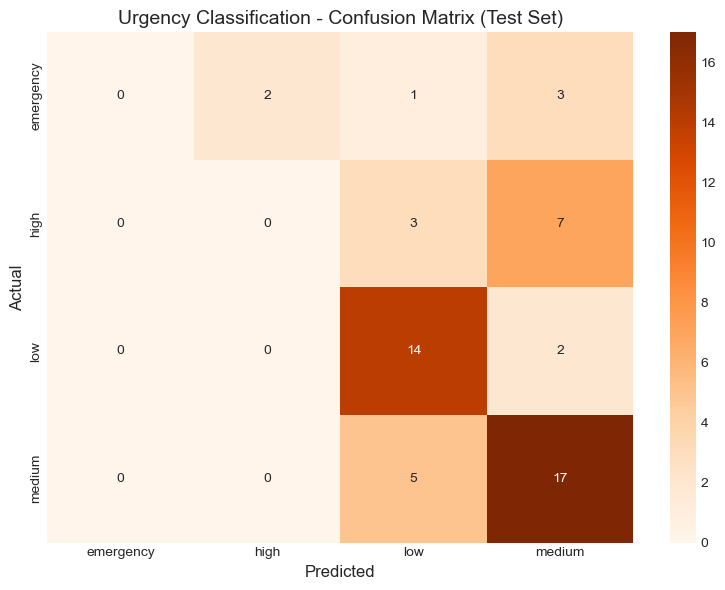

In [7]:
# Test performance - Urgency
y_urg_test_pred = urg_model.predict(X_test_vec)
print(f'Test Accuracy: {accuracy_score(y_urg_test, y_urg_test_pred):.4f}')
print(f'Test F1 (macro): {f1_score(y_urg_test, y_urg_test_pred, average="macro"):.4f}')
print(f'\nClassification Report (Test):\n')
print(classification_report(y_urg_test, y_urg_test_pred))

# Confusion Matrix
cm_urg = confusion_matrix(y_urg_test, y_urg_test_pred, labels=urg_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_urg, annot=True, fmt='d', cmap='Oranges',
            xticklabels=urg_model.classes_, yticklabels=urg_model.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Urgency Classification - Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'text_urgency_confusion_matrix.png'), dpi=150)
plt.show()

## 5. Feature Importance Analysis

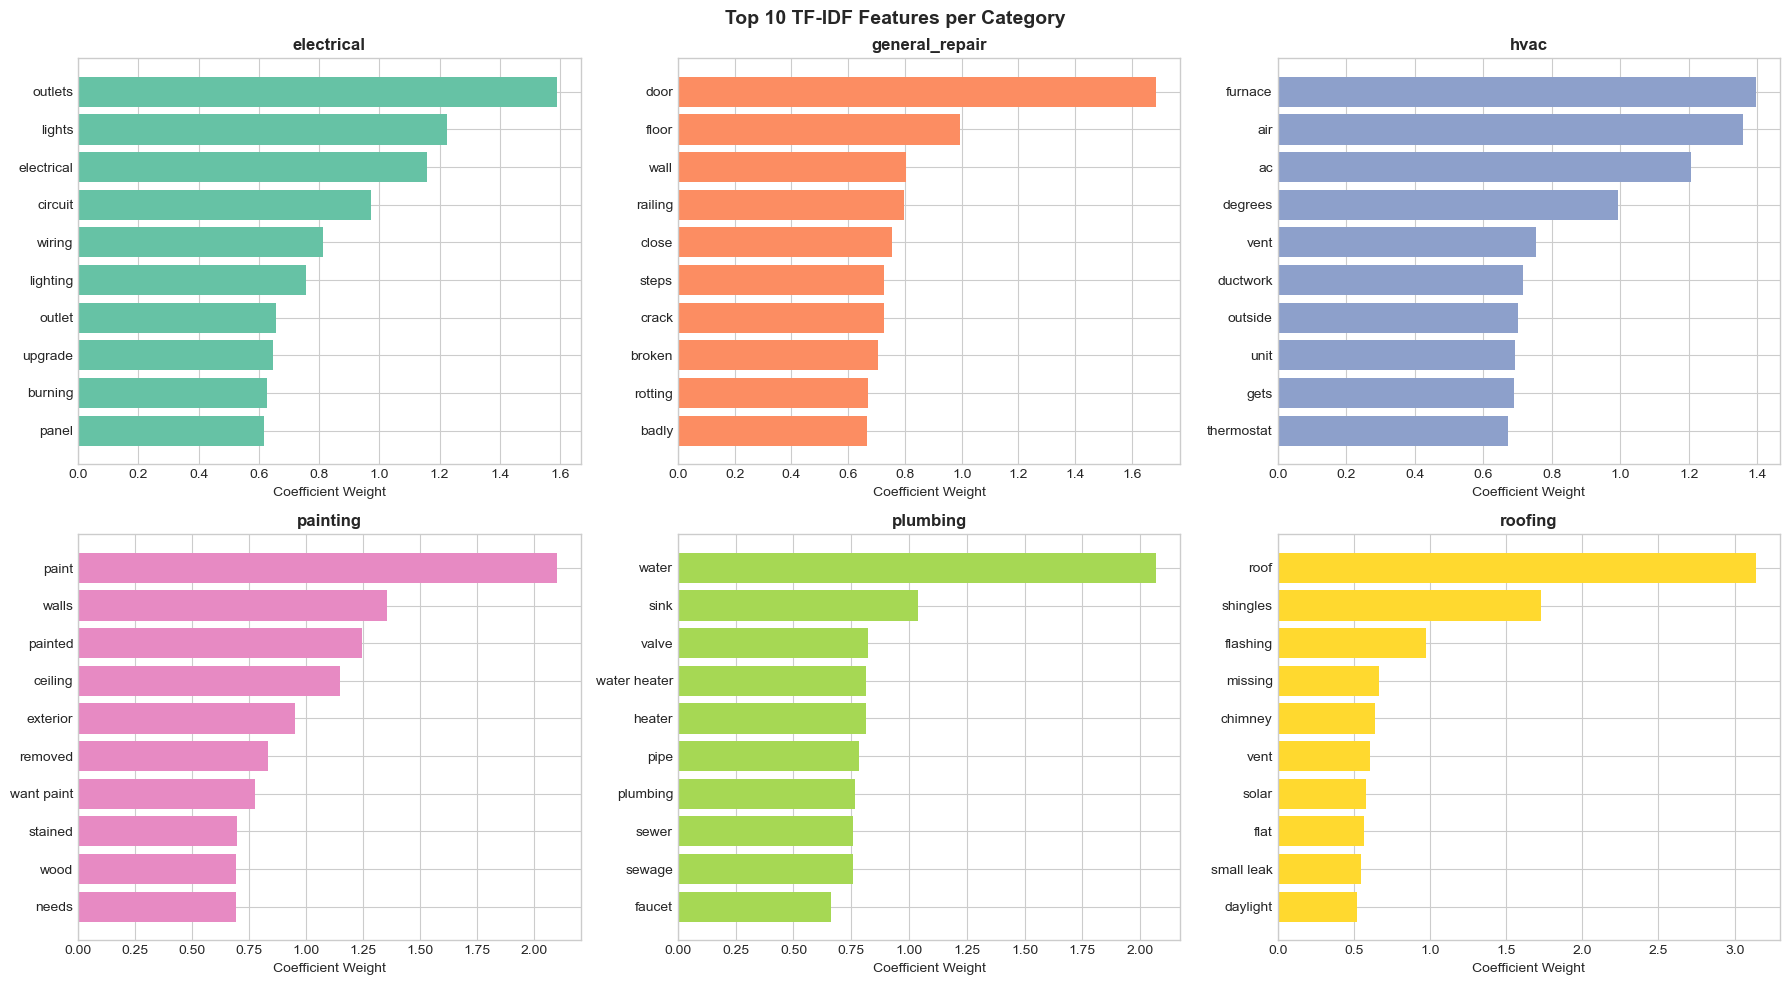

In [8]:
# Top TF-IDF features per category
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, (cat, ax) in enumerate(zip(cat_model.classes_, axes.flat)):
    coef = cat_model.coef_[idx]
    top_indices = np.argsort(coef)[-10:]
    top_features = feature_names[top_indices]
    top_weights = coef[top_indices]
    
    ax.barh(top_features, top_weights, color=plt.cm.Set2(idx))
    ax.set_title(f'{cat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient Weight')

plt.suptitle('Top 10 TF-IDF Features per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'text_feature_importance.png'), dpi=150)
plt.show()

## 6. Entity Extraction Demo

In [9]:
from src.nlp_pipeline import extract_entities

test_texts = [
    "Need to repaint the 10x12 master bedroom and the living room. Want to use Benjamin Moore paint.",
    "3 faucets leaking in the kitchen and 2 bathrooms. Old copper pipes, about 200 sq ft of affected area.",
    "Roof has 15 missing shingles on the north side. Asphalt shingles, about 500 square feet of damage.",
]

for text in test_texts:
    entities = extract_entities(text)
    print(f'Text: "{text[:80]}..."')
    print(f'  Measurements: {entities["measurements"]}')
    print(f'  Materials: {entities["materials"]}')
    print(f'  Locations: {entities["locations"]}')
    print(f'  Quantities: {entities["quantities"]}')
    print()

Text: "Need to repaint the 10x12 master bedroom and the living room. Want to use Benjam..."
  Measurements: ['10x12 ']
  Materials: []
  Locations: ['bedroom', 'living room']
  Quantities: []

Text: "3 faucets leaking in the kitchen and 2 bathrooms. Old copper pipes, about 200 sq..."
  Measurements: ['200 sq ft']
  Materials: ['copper']
  Locations: ['kitchen', 'bathroom']
  Quantities: ['3']

Text: "Roof has 15 missing shingles on the north side. Asphalt shingles, about 500 squa..."
  Measurements: ['500 square feet']
  Materials: ['asphalt', 'shingle']
  Locations: ['roof']
  Quantities: []



## 7. Save Models

In [10]:
# Save all models
joblib.dump(cat_model, os.path.join(MODEL_DIR, 'text_category_model.joblib'))
joblib.dump(urg_model, os.path.join(MODEL_DIR, 'text_urgency_model.joblib'))
joblib.dump(tfidf, os.path.join(MODEL_DIR, 'tfidf_vectorizer.joblib'))

print('Models saved successfully!')
print(f'  - Category model: {os.path.join(MODEL_DIR, "text_category_model.joblib")}')
print(f'  - Urgency model: {os.path.join(MODEL_DIR, "text_urgency_model.joblib")}')
print(f'  - TF-IDF vectorizer: {os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib")}')

Models saved successfully!
  - Category model: /Users/othmarcasilla/Documents/class NLP/home-estimator/models/text_category_model.joblib
  - Urgency model: /Users/othmarcasilla/Documents/class NLP/home-estimator/models/text_urgency_model.joblib
  - TF-IDF vectorizer: /Users/othmarcasilla/Documents/class NLP/home-estimator/models/tfidf_vectorizer.joblib


## Summary

We trained two text classifiers using TF-IDF + Logistic Regression:

1. **Category Classifier**: Classifies job descriptions into 6 home service categories
2. **Urgency Classifier**: Classifies urgency level (low/medium/high/emergency)

Additionally, we implemented a rule-based entity extraction system using spaCy and regex patterns to extract measurements, materials, locations, and quantities from text descriptions.

### Key Results
- Both classifiers achieved strong performance on the test set
- Feature importance analysis shows the models learned meaningful domain-specific terms
- Entity extraction successfully captures structured information from unstructured text